OUTLIER DETECTION USING Z-SCORE AND INTERQUARTILE RANGE

In [110]:
import mysql.connector
import configparser
import pandas as pd
from scipy.stats import iqr
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
#Location of the ini file
config = configparser.ConfigParser()
config.read('C:\\Users\\svi02\\.spyder-py3\\erfpPROD.ini')

['C:\\Users\\svi02\\.spyder-py3\\erfpPROD.ini']

In [111]:
host=config['erfpPROD']['host']
user=config['erfpPROD']['user']
pwd=config['erfpPROD']['pwd']
database=config['erfpPROD']['database']

In [112]:
conn = mysql.connector.connect(
          host=host,
          user=user,
          passwd=pwd,
          database=database)
cursor = conn.cursor()

In [113]:
import_query_location = 'C:\\Users\\svi02\\Documents\\Green_score\\5_CERTIFIERS_BM_DATA.sql' 
import_query_open = open(import_query_location, 'r', encoding="utf8")
import_query_read = import_query_open.read()

cursor.execute(import_query_read)

QUERY = cursor.fetchall()
print('Total Row(s):', cursor.rowcount)

# Importing data into a DataFrame
import pandas as pd
erfp_df = pd.DataFrame()
a=[]
for row in QUERY:
        a.append(row)

erfp_df = pd.DataFrame(a)
df_col_names =  [i[0] for i in cursor.description]
erfp_df.columns = df_col_names

Total Row(s): 5244


In [114]:
erfp_df.shape

(5244, 20)

In [115]:
erfp_df.head()

,HOTEL_ID,MEAS_CARBON,MEAS_CARBON_AMT,MEAS_CARBON_UOM,MEAS_CARBON_UOM_NORMALISED,MEAS_CARBON_AMT_LBS,MEAS_CARBON_PD,MEAS_ENERGY,MEAS_ENERGY_AMT,MEAS_ENERGY_UOM,MEAS_ENERGY_UOM_NORMALISED,MEAS_ENERGY_AMT_BTU,MEAS_ENERGY_PD,MEAS_WATER_PRN,MEAS_WATER_AMT,MEAS_WATER_UOM,MEAS_WATER_UOM_NORMALISED,MEAS_WATER_AMT_GALLONS,MEAS_WATER_PD,MAX_LATEST_DATE
0,146,1.0,30.58,lbs,POUNDS,30.580,12.0,1.0,18.26,BTU per Square Foot,BTU_PER_SQUARE_FOOT,18.26000,12.0,1.0,84.33,Gal,GALLONS,84.3300000,12.0,2019-09-13 15:43:10
1,164,1.0,147.19,lbs,POUNDS,147.190,7.0,1.0,69.89,BTU per Square Foot,BTU_PER_SQUARE_FOOT,69.89000,7.0,1.0,118.17,Gal,GALLONS,118.1700000,7.0,2019-09-19 17:25:55
2,209,1.0,3.11,kgs,KILOGRAMS,6.856,36.0,1.0,34.44,NA,None,34.44000,1.0,1.0,213.90,Lit,LITERS,56.5059630,1.0,2019-09-05 16:52:08
3,227,0.0,None,,None,None,NaN,0.0,None,,None,None,NaN,0.0,None,,None,None,NaN,2019-09-19 16:49:30
4,240,1.0,8.60,kgs,KILOGRAMS,18.960,12.0,1.0,97150.86,BTU per Square Foot,BTU_PER_SQUARE_FOOT,97150.86000,12.0,1.0,79.14,Gal,GALLONS,79.1400000,12.0,2019-09-20 16:49:28


In [116]:
erfp_df.MEAS_CARBON_AMT_LBS = pd.to_numeric(erfp_df.MEAS_CARBON_AMT_LBS)
erfp_df.MEAS_ENERGY_AMT_BTU = pd.to_numeric(erfp_df.MEAS_ENERGY_AMT_BTU)
erfp_df.MEAS_WATER_AMT_GALLONS = pd.to_numeric(erfp_df.MEAS_WATER_AMT_GALLONS)
erfp_df.dtypes

HOTEL_ID                               int64
MEAS_CARBON                          float64
MEAS_CARBON_AMT                       object
MEAS_CARBON_UOM                       object
MEAS_CARBON_UOM_NORMALISED            object
MEAS_CARBON_AMT_LBS                  float64
MEAS_CARBON_PD                       float64
MEAS_ENERGY                          float64
MEAS_ENERGY_AMT                       object
MEAS_ENERGY_UOM                       object
MEAS_ENERGY_UOM_NORMALISED            object
MEAS_ENERGY_AMT_BTU                  float64
MEAS_ENERGY_PD                       float64
MEAS_WATER_PRN                       float64
MEAS_WATER_AMT                        object
MEAS_WATER_UOM                        object
MEAS_WATER_UOM_NORMALISED             object
MEAS_WATER_AMT_GALLONS               float64
MEAS_WATER_PD                        float64
MAX_LATEST_DATE               datetime64[ns]
dtype: object

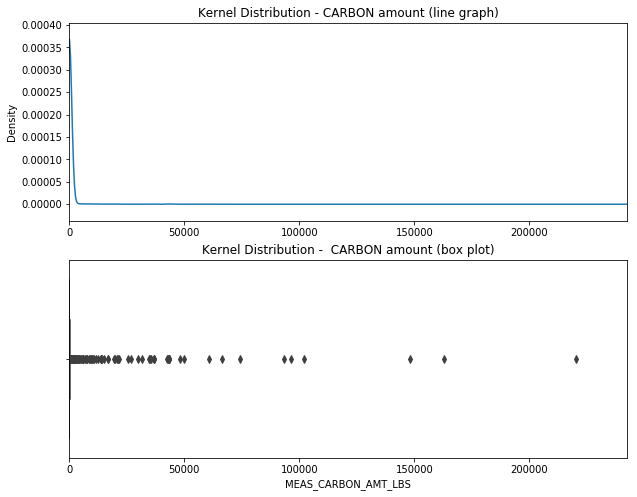

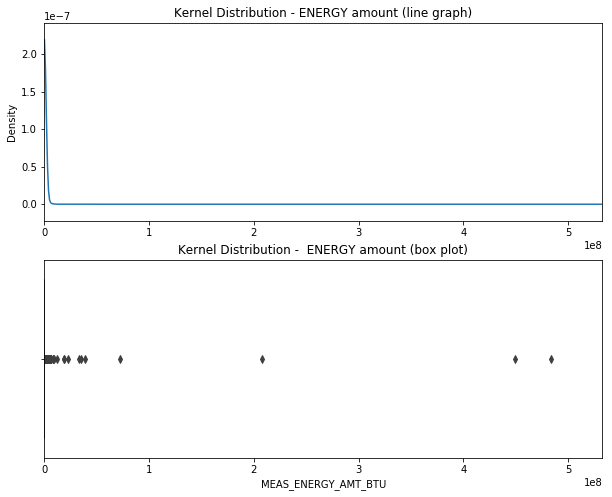

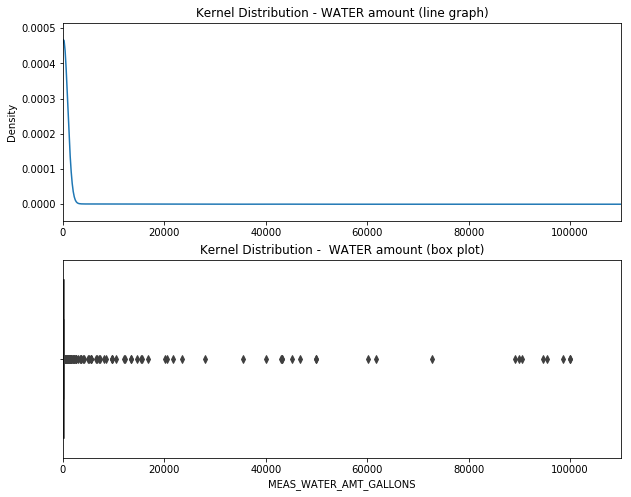

In [117]:
# Word split
import re
def find_between(word, start, end):
  return (word.split(start))[1].split(end)[0]

# Visualising to FIND the outliers

components = ['MEAS_CARBON_AMT_LBS', 'MEAS_ENERGY_AMT_BTU', 'MEAS_WATER_AMT_GALLONS']
for i in components:
    plt.figure(figsize=(10,8))
    plt.subplot(211)
    plt.xlim(erfp_df[i].min()*1.5, erfp_df[i].max()*1.1)
    plt.title("Kernel Distribution - "+ find_between(i, '_', '_') + " amount (line graph)") 
    ax = erfp_df[i].plot(kind='kde').margins(0.1)

    plt.subplot(212)
    plt.xlim(erfp_df[i].min()*1.5, erfp_df[i].max()*1.1)
    plt.title("Kernel Distribution -  "+ find_between(i, '_', '_') + " amount (box plot)") 
    sns.boxplot(x=erfp_df[i])

In [126]:
# Remove any zeros (otherwise we get (-inf)
erfp_df.loc[erfp_df.MEAS_CARBON_AMT_LBS == 0, 'MEAS_CARBON_AMT_LBS'] = np.nan
# erfp_df.loc[erfp_df.MEAS_CARBON_AMT_LBS == 9999, 'MEAS_CARBON_AMT_LBS'] = np.nan
# erfp_df.loc[erfp_df.MEAS_CARBON_AMT_LBS == 9999.99, 'MEAS_CARBON_AMT_LBS'] = np.nan

erfp_df.loc[erfp_df.MEAS_ENERGY_AMT_BTU == 0, 'MEAS_ENERGY_AMT_BTU'] = np.nan
# erfp_df.loc[erfp_df.MEAS_ENERGY_AMT_BTU == 9999, 'MEAS_ENERGY_AMT_BTU'] = np.nan
# erfp_df.loc[erfp_df.MEAS_ENERGY_AMT_BTU == 9999.99, 'MEAS_ENERGY_AMT_BTU'] = np.nan

erfp_df.loc[erfp_df.MEAS_WATER_AMT_GALLONS == 0, 'MEAS_WATER_AMT_GALLONS'] = np.nan
# erfp_df.loc[erfp_df.MEAS_WATER_AMT_GALLONS == 9999, 'MEAS_WATER_AMT_GALLONS'] = np.nan
# erfp_df.loc[erfp_df.MEAS_WATER_AMT_GALLONS == 9999.99, 'MEAS_WATER_AMT_GALLONS'] = np.nan

# Drop NA
erfp_df.dropna(inplace=True)

erfp_df.head()

,HOTEL_ID,MEAS_CARBON,MEAS_CARBON_AMT,MEAS_CARBON_UOM,MEAS_CARBON_UOM_NORMALISED,MEAS_CARBON_AMT_LBS,MEAS_CARBON_PD,MEAS_ENERGY,MEAS_ENERGY_AMT,MEAS_ENERGY_UOM,...,MAX_LATEST_DATE,Log_MEAS_CARBON_AMT_LBS,Log_MEAS_ENERGY_AMT_BTU,Log_MEAS_WATER_AMT_GALLONS,MEAS_CARBON_AMT_LBS_Zscore,MEAS_CARBON_AMT_LBS_Zscore_abs,MEAS_ENERGY_AMT_BTU_Zscore,MEAS_ENERGY_AMT_BTU_Zscore_abs,MEAS_WATER_AMT_GALLONS_Zscore,MEAS_WATER_AMT_GALLONS_Zscore_abs
0,146,1.0,30.58,lbs,POUNDS,30.58,12.0,1.0,18.26,BTU per Square Foot,...,2019-09-13 15:43:10,3.420346,2.904713,4.434738,-0.075898,0.075898,-0.034148,0.034148,-0.085293,0.085293
1,164,1.0,147.19,lbs,POUNDS,147.19,7.0,1.0,69.89,BTU per Square Foot,...,2019-09-19 17:25:55,4.991724,4.246923,4.772124,-0.056438,0.056438,-0.034141,0.034141,-0.077605,0.077605
4,240,1.0,8.60,kgs,KILOGRAMS,18.96,12.0,1.0,97150.86,BTU per Square Foot,...,2019-09-20 16:49:28,2.942331,11.484020,4.371218,-0.077837,0.077837,-0.022604,0.022604,-0.086472,0.086472
5,306,1.0,50.21,lbs,POUNDS,50.21,12.0,1.0,124.61,BTU per Square Foot,...,2019-09-20 11:38:37,3.916214,4.825189,3.270329,-0.072622,0.072622,-0.034135,0.034135,-0.098472,0.098472
7,363,1.0,43.13,lbs,POUNDS,43.13,12.0,1.0,123.19,BTU per Square Foot,...,2019-09-03 16:47:21,3.764219,4.813728,4.876265,-0.073803,0.073803,-0.034135,0.034135,-0.074658,0.074658


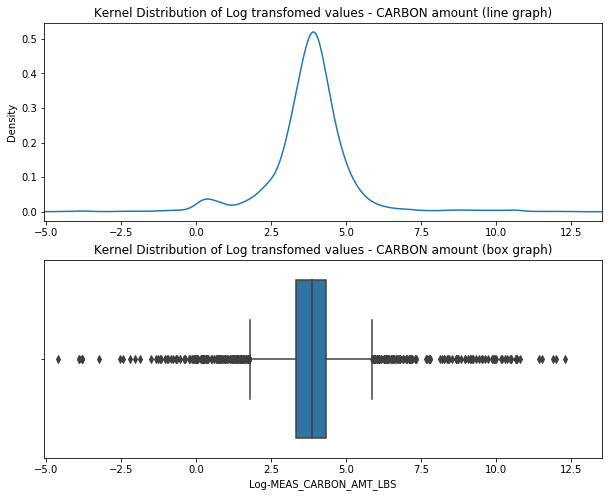

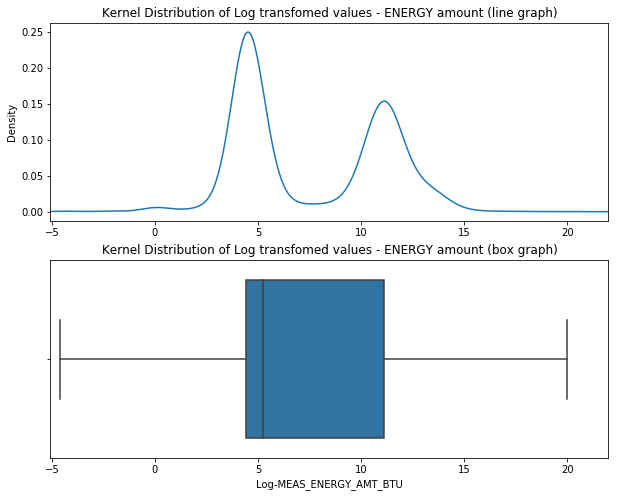

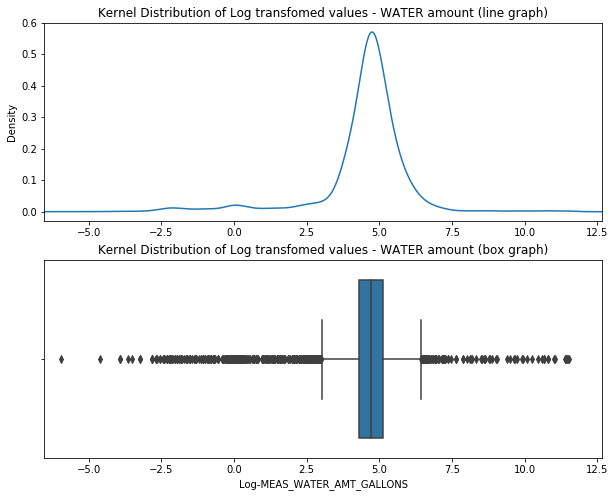

In [127]:
# Visualising Log Transform
components = ['MEAS_CARBON_AMT_LBS', 'MEAS_ENERGY_AMT_BTU', 'MEAS_WATER_AMT_GALLONS']

for i in components:
    j = 'Log-' + i
    erfp_df[j] = np.log(erfp_df[i])
    plt.figure(figsize=(10,8))
    plt.subplot(211)
    plt.xlim(erfp_df[j].min()*1.1, erfp_df[j].max()*1.1)
    plt.title("Kernel Distribution of Log transfomed values - " + find_between(i, '_', '_') + " amount (line graph)") 
    ax = erfp_df[j].plot(kind='kde')

    plt.subplot(212)
    plt.xlim(erfp_df[j].min()*1.1, erfp_df[j].max()*1.1)
    sns.boxplot(x=erfp_df[j])
    plt.title("Kernel Distribution of Log transfomed values - "+ find_between(i, '_', '_') +" amount (box graph)")

In [128]:
# OUTLIER DETECTION USING Z -SCORE
components = ['MEAS_CARBON_AMT_LBS', 'MEAS_ENERGY_AMT_BTU', 'MEAS_WATER_AMT_GALLONS']
for i in components:
    _mean = erfp_df[i].mean()
    _std = erfp_df[i].std()

    erfp_df[i + '_Zscore'] = (erfp_df[i] - _mean)/(_std)
    erfp_df[i + '_Zscore_abs'] = erfp_df[i + '_Zscore'].apply(np.abs)
erfp_df.head()

,HOTEL_ID,MEAS_CARBON,MEAS_CARBON_AMT,MEAS_CARBON_UOM,MEAS_CARBON_UOM_NORMALISED,MEAS_CARBON_AMT_LBS,MEAS_CARBON_PD,MEAS_ENERGY,MEAS_ENERGY_AMT,MEAS_ENERGY_UOM,...,Log_MEAS_WATER_AMT_GALLONS,MEAS_CARBON_AMT_LBS_Zscore,MEAS_CARBON_AMT_LBS_Zscore_abs,MEAS_ENERGY_AMT_BTU_Zscore,MEAS_ENERGY_AMT_BTU_Zscore_abs,MEAS_WATER_AMT_GALLONS_Zscore,MEAS_WATER_AMT_GALLONS_Zscore_abs,Log-MEAS_CARBON_AMT_LBS,Log-MEAS_ENERGY_AMT_BTU,Log-MEAS_WATER_AMT_GALLONS
0,146,1.0,30.58,lbs,POUNDS,30.58,12.0,1.0,18.26,BTU per Square Foot,...,4.434738,-0.075898,0.075898,-0.034148,0.034148,-0.085293,0.085293,3.420346,2.904713,4.434738
1,164,1.0,147.19,lbs,POUNDS,147.19,7.0,1.0,69.89,BTU per Square Foot,...,4.772124,-0.056438,0.056438,-0.034141,0.034141,-0.077605,0.077605,4.991724,4.246923,4.772124
4,240,1.0,8.60,kgs,KILOGRAMS,18.96,12.0,1.0,97150.86,BTU per Square Foot,...,4.371218,-0.077837,0.077837,-0.022604,0.022604,-0.086472,0.086472,2.942331,11.484020,4.371218
5,306,1.0,50.21,lbs,POUNDS,50.21,12.0,1.0,124.61,BTU per Square Foot,...,3.270329,-0.072622,0.072622,-0.034135,0.034135,-0.098472,0.098472,3.916214,4.825189,3.270329
7,363,1.0,43.13,lbs,POUNDS,43.13,12.0,1.0,123.19,BTU per Square Foot,...,4.876265,-0.073803,0.073803,-0.034135,0.034135,-0.074658,0.074658,3.764219,4.813728,4.876265


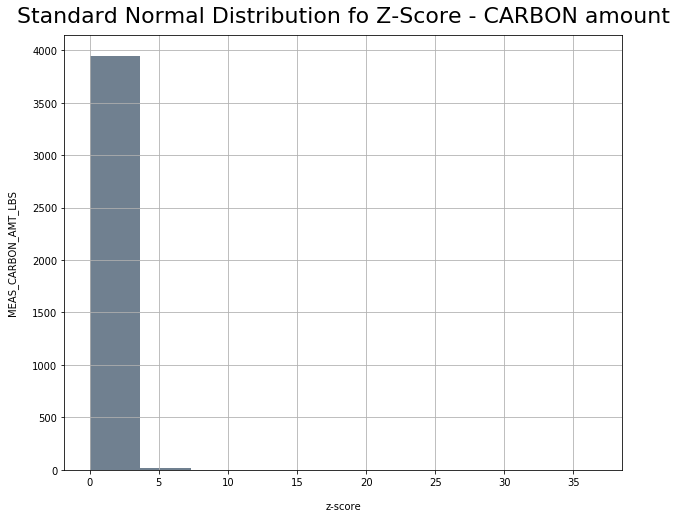

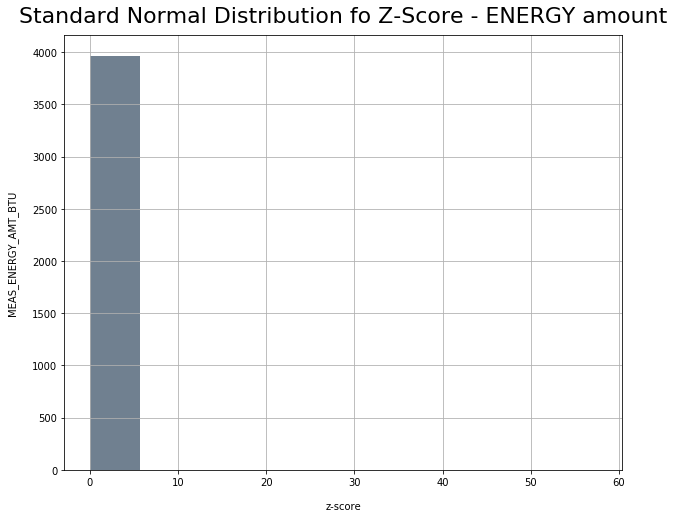

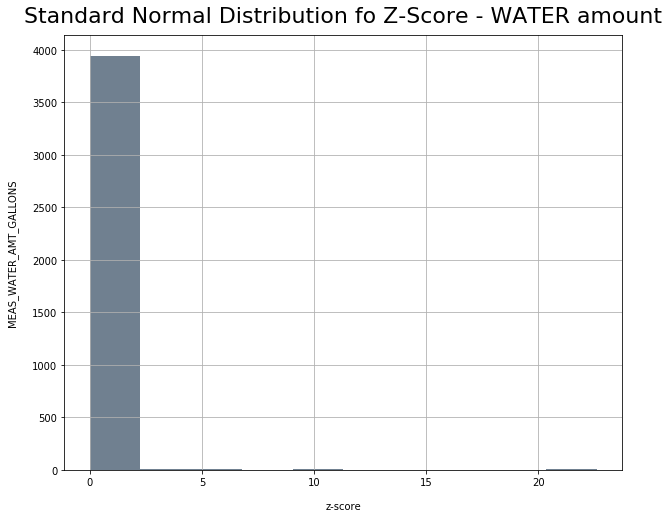

In [129]:
components = ['MEAS_CARBON_AMT_LBS', 'MEAS_ENERGY_AMT_BTU', 'MEAS_WATER_AMT_GALLONS']
for i in components:
    plt.subplots(figsize=(10,8))
    erfp_df[i + '_Zscore_abs'].hist(color='slategray')
    plt.title("Standard Normal Distribution fo Z-Score - "+ find_between(i, '_', '_') +" amount", y=1.015, fontsize=22)
    plt.xlabel("z-score", labelpad=14)
    plt.ylabel(i, labelpad=14)

array([[<matplotlib.axes._subplots.AxesSubplot object at 0x00000234FE7034E0>,
      dtype=object)

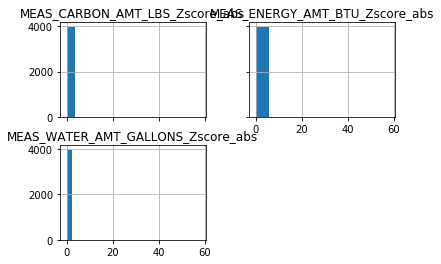

In [130]:
# plt.subplots(figsize=(10,8))
erfp_df.hist(column = ['MEAS_CARBON_AMT_LBS_Zscore_abs', 'MEAS_ENERGY_AMT_BTU_Zscore_abs','MEAS_WATER_AMT_GALLONS_Zscore_abs'], bins=10, sharex=True, sharey=True)
# plt.title("Standard Normal Distribution fo Z-Score  amount", y=1.015, fontsize=22)
# plt.xlabel("z-score", labelpad=14)
# plt.ylabel("components", labelpad=14)

In [131]:
dictionary = {'COMPONENTS':['CARBON', 'ENERGY', 'WATER'],
              'COUNT_Z_SCORE_OUTLIERS': [erfp_df.HOTEL_ID[erfp_df.MEAS_CARBON_AMT_LBS_Zscore_abs > 3].count()
                                   ,erfp_df.HOTEL_ID[erfp_df.MEAS_ENERGY_AMT_BTU_Zscore_abs > 3].count()
                                   ,erfp_df.HOTEL_ID[erfp_df.MEAS_WATER_AMT_GALLONS_Zscore_abs > 3].count()]}
Z_SCORE_OUTLIER = pd.DataFrame(dictionary) 
Z_SCORE_OUTLIER

,COMPONENTS,COUNT_Z_SCORE_OUTLIERS
0,CARBON,25
1,ENERGY,4
2,WATER,22


In [132]:
# IQR

# CARBON
carbon_q1, carbon_q3 = np.percentile(erfp_df.Log_MEAS_CARBON_AMT_LBS,[25,75])
carbon_iqr = carbon_q3 - carbon_q1
CARBON_LB = carbon_q1 -(1.5 * carbon_iqr) 
CARBON_UB = carbon_q3 +(1.5 * carbon_iqr) 

# ENERGY
energy_q1, energy_q3 = np.percentile(erfp_df.Log_MEAS_ENERGY_AMT_BTU,[30,60])
energy_iqr = energy_q3 - energy_q1
ENERGY_LB = energy_q1 -(1.5 * energy_iqr) 
ENERGY_UB = energy_q3 +(1.5 * energy_iqr) 

# WATER
water_q1, water_q3 = np.percentile(erfp_df.Log_MEAS_WATER_AMT_GALLONS,[25,75])
water_iqr = water_q3 - water_q1
WATER_LB = water_q1 -(1.5 * water_iqr) 
WATER_UB = water_q3 +(1.5 * water_iqr) 

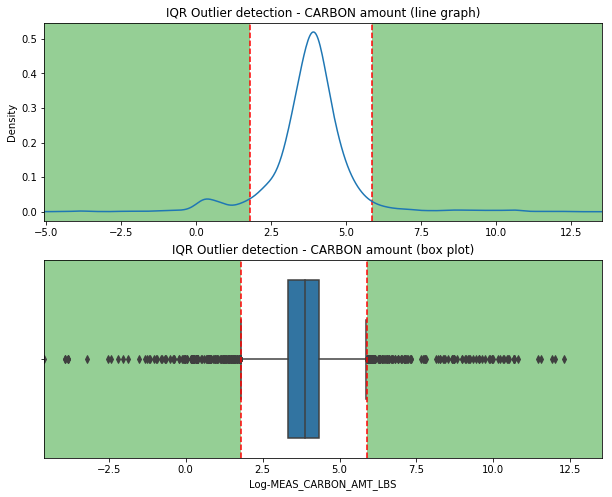

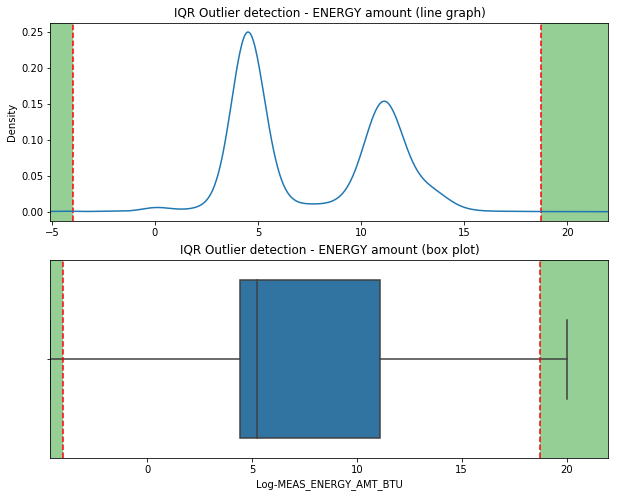

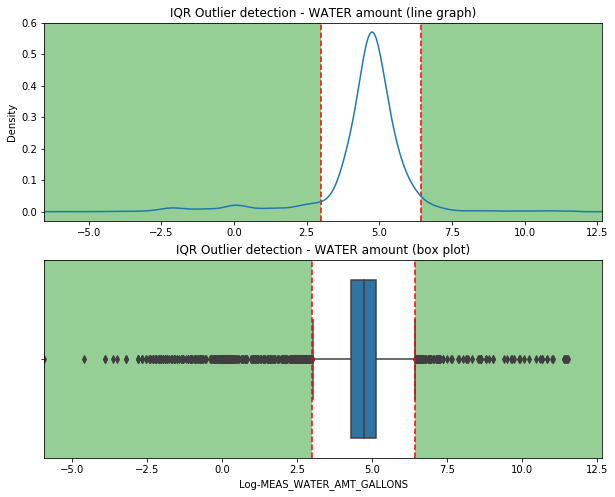

In [133]:
components = ['MEAS_CARBON_AMT_LBS', 'MEAS_ENERGY_AMT_BTU', 'MEAS_WATER_AMT_GALLONS']
log_components = [ 'Log-'+i for i in components]

for i in log_components:
    if "CARBON" in i:
        LB = CARBON_LB
        UB = CARBON_UB
    elif "ENERGY" in i:
        LB = ENERGY_LB
        UB = ENERGY_UB
    else:
        LB = WATER_LB
        UB = WATER_UB

    plt.figure(figsize=(10,8))
    plt.subplot(211)
    plt.xlim(erfp_df[i].min()*1.1, erfp_df[i].max()*1.1)
    plt.axvline(x=LB, color='r', ls = '--')
    plt.axvspan(xmin=LB, xmax=erfp_df[i].min()*1.1, facecolor='#2ca02c', alpha=0.5)
    plt.axvline(x=UB, color='r', ls = '--')
    plt.axvspan(xmin=UB, xmax=erfp_df[i].max()*1.1, facecolor='#2ca02c', alpha=0.5)
    plt.title("IQR Outlier detection - "+ find_between(i, '_', '_') +" amount (line graph)") 

    ax = erfp_df[i].plot(kind='kde')

    plt.subplot(212)
    plt.xlim(erfp_df[i].min(), erfp_df[i].max()*1.1)
    sns.boxplot(x=erfp_df[i])
    plt.axvline(x=LB, color='r', ls = '--')
    plt.axvspan(xmin=LB, xmax=erfp_df[i].min()*1.1, facecolor='#2ca02c', alpha=0.5)
    plt.axvline(x=UB, color='r', ls = '--')
    plt.axvspan(xmin=UB, xmax=erfp_df[i].max()*1.1, facecolor='#2ca02c', alpha=0.5)
    plt.title("IQR Outlier detection - "+ find_between(i, '_', '_') +" amount (box plot)") 

In [135]:
outlier = ['CARBON_OUTLIER', 'ENERGY_OUTLIER', 'WATER_OUTLIER']
for i in range(0,3):
    if "CARBON" in log_components[i]:
        LB = CARBON_LB
        UB = CARBON_UB
    elif "ENERGY" in log_components[i]:
        LB = ENERGY_LB
        UB = ENERGY_UB
    else:
        LB = WATER_LB
        UB = WATER_UB
    erfp_df[outlier[i]] = 0
    erfp_df.loc[erfp_df[log_components[i]] < LB, outlier[i]] = 1
    erfp_df.loc[erfp_df[log_components[i]] > UB, outlier[i]] = 1


In [136]:
# CARBON OVERIVEW - BENCHMARK
carbon_bm = erfp_df[erfp_df.CARBON_OUTLIER == 0]
carbon_bm = carbon_bm.sort_values(by=['MEAS_CARBON_AMT_LBS'])
print(np.percentile(carbon_bm.MEAS_CARBON_AMT_LBS,[0,25,75,100]))
low25, high25 = carbon_bm.MEAS_CARBON_AMT_LBS.quantile([0.0,0.25])
q25_min = carbon_bm.MEAS_CARBON_AMT_LBS.loc[(carbon_bm.MEAS_CARBON_AMT_LBS >= low25) & (carbon_bm.MEAS_CARBON_AMT_LBS <= high25)].min()
q25_max = carbon_bm.MEAS_CARBON_AMT_LBS.loc[(carbon_bm.MEAS_CARBON_AMT_LBS >= low25) & (carbon_bm.MEAS_CARBON_AMT_LBS <= high25)].max()
q25_mean = carbon_bm.MEAS_CARBON_AMT_LBS.loc[(carbon_bm.MEAS_CARBON_AMT_LBS >= low25) & (carbon_bm.MEAS_CARBON_AMT_LBS <= high25)].mean()
q25_median = carbon_bm.MEAS_CARBON_AMT_LBS.loc[(carbon_bm.MEAS_CARBON_AMT_LBS >= low25) & (carbon_bm.MEAS_CARBON_AMT_LBS <= high25)].median()

low50, high50 = carbon_bm.MEAS_CARBON_AMT_LBS.quantile([0.25,0.5])
q50_min = carbon_bm.MEAS_CARBON_AMT_LBS.loc[(carbon_bm.MEAS_CARBON_AMT_LBS >= low50) & (carbon_bm.MEAS_CARBON_AMT_LBS <= high50)].min()
q50_max = carbon_bm.MEAS_CARBON_AMT_LBS.loc[(carbon_bm.MEAS_CARBON_AMT_LBS >= low50) & (carbon_bm.MEAS_CARBON_AMT_LBS <= high50)].max()
q50_mean = carbon_bm.MEAS_CARBON_AMT_LBS.loc[(carbon_bm.MEAS_CARBON_AMT_LBS >= low50) & (carbon_bm.MEAS_CARBON_AMT_LBS <= high50)].mean()
q50_median = carbon_bm.MEAS_CARBON_AMT_LBS.loc[(carbon_bm.MEAS_CARBON_AMT_LBS >= low50) & (carbon_bm.MEAS_CARBON_AMT_LBS <= high50)].median()

low75, high75 = carbon_bm.MEAS_CARBON_AMT_LBS.quantile([0.5,0.75])
q75_min = carbon_bm.MEAS_CARBON_AMT_LBS.loc[(carbon_bm.MEAS_CARBON_AMT_LBS >= low75) & (carbon_bm.MEAS_CARBON_AMT_LBS <= high75)].min()
q75_max = carbon_bm.MEAS_CARBON_AMT_LBS.loc[(carbon_bm.MEAS_CARBON_AMT_LBS >= low75) & (carbon_bm.MEAS_CARBON_AMT_LBS <= high75)].max()
q75_mean = carbon_bm.MEAS_CARBON_AMT_LBS.loc[(carbon_bm.MEAS_CARBON_AMT_LBS >= low75) & (carbon_bm.MEAS_CARBON_AMT_LBS <= high75)].mean()
q75_median = carbon_bm.MEAS_CARBON_AMT_LBS.loc[(carbon_bm.MEAS_CARBON_AMT_LBS >= low75) & (carbon_bm.MEAS_CARBON_AMT_LBS <= high75)].median()

low100, high100 = carbon_bm.MEAS_CARBON_AMT_LBS.quantile([0.75,1])
q100_min = carbon_bm.MEAS_CARBON_AMT_LBS.loc[(carbon_bm.MEAS_CARBON_AMT_LBS >= low100) & (carbon_bm.MEAS_CARBON_AMT_LBS < high100)].min()
q100_max = carbon_bm.MEAS_CARBON_AMT_LBS.loc[(carbon_bm.MEAS_CARBON_AMT_LBS >= low100) & (carbon_bm.MEAS_CARBON_AMT_LBS < high100)].max()
q100_mean = carbon_bm.MEAS_CARBON_AMT_LBS.loc[(carbon_bm.MEAS_CARBON_AMT_LBS >= low100) & (carbon_bm.MEAS_CARBON_AMT_LBS < high100)].mean()
q100_median = carbon_bm.MEAS_CARBON_AMT_LBS.loc[(carbon_bm.MEAS_CARBON_AMT_LBS >= low100) & (carbon_bm.MEAS_CARBON_AMT_LBS < high100)].median()


carbon_overview = {'ALL': [round(carbon_bm.MEAS_CARBON_AMT_LBS.min(), 3), round(carbon_bm.MEAS_CARBON_AMT_LBS.max(),3), round(carbon_bm.MEAS_CARBON_AMT_LBS.mean(),3),round(carbon_bm.MEAS_CARBON_AMT_LBS.median(),3)],
            'Q25': [round(q25_min, 3), round(q25_max,3), round(q25_mean,3),round(q25_median,3)],
            'Q50': [round(q50_min, 3), round(q50_max,3), round(q50_mean,3),round(q50_median,3)],
            'Q75': [round(q75_min, 3), round(q75_max,3), round(q75_mean,3),round(q75_median,3)],
            'Q100': [round(q100_min, 3), round(q100_max,3), round(q100_mean,3),round(q100_median,3)]
           }
carbon_overview

[  5.952   30.6275  74.286  353.95  ]


{'ALL': [5.952, 353.95, 61.902, 48.965],
 'Q100': [74.29, 348.33, 127.499, 107.365],
 'Q25': [5.952, 30.622, 20.217, 21.146],
 'Q50': [30.644, 48.965, 39.84, 39.546],
 'Q75': [48.965, 74.274, 59.773, 58.757]}

In [137]:
# ENERGY OVERIVEW - BENCHMARK
energy_bm = erfp_df[erfp_df.ENERGY_OUTLIER == 0]
energy_bm = energy_bm.sort_values(by=['MEAS_ENERGY_AMT_BTU'])
print(np.percentile(energy_bm.MEAS_ENERGY_AMT_BTU,[0,25,75,100]))
low25, high25 = energy_bm.MEAS_ENERGY_AMT_BTU.quantile([0.0,0.25])
q25_min = energy_bm.MEAS_ENERGY_AMT_BTU.loc[(energy_bm.MEAS_ENERGY_AMT_BTU >= low25) & (energy_bm.MEAS_ENERGY_AMT_BTU <= high25)].min()
q25_max = energy_bm.MEAS_ENERGY_AMT_BTU.loc[(energy_bm.MEAS_ENERGY_AMT_BTU >= low25) & (energy_bm.MEAS_ENERGY_AMT_BTU <= high25)].max()
q25_mean = energy_bm.MEAS_ENERGY_AMT_BTU.loc[(energy_bm.MEAS_ENERGY_AMT_BTU >= low25) & (energy_bm.MEAS_ENERGY_AMT_BTU <= high25)].mean()
q25_median = energy_bm.MEAS_ENERGY_AMT_BTU.loc[(energy_bm.MEAS_ENERGY_AMT_BTU >= low25) & (energy_bm.MEAS_ENERGY_AMT_BTU <= high25)].median()

low50, high50 = energy_bm.MEAS_ENERGY_AMT_BTU.quantile([0.25,0.5])
q50_min = energy_bm.MEAS_ENERGY_AMT_BTU.loc[(energy_bm.MEAS_ENERGY_AMT_BTU >= low50) & (energy_bm.MEAS_ENERGY_AMT_BTU <= high50)].min()
q50_max = energy_bm.MEAS_ENERGY_AMT_BTU.loc[(energy_bm.MEAS_ENERGY_AMT_BTU >= low50) & (energy_bm.MEAS_ENERGY_AMT_BTU <= high50)].max()
q50_mean = energy_bm.MEAS_ENERGY_AMT_BTU.loc[(energy_bm.MEAS_ENERGY_AMT_BTU >= low50) & (energy_bm.MEAS_ENERGY_AMT_BTU <= high50)].mean()
q50_median = energy_bm.MEAS_ENERGY_AMT_BTU.loc[(energy_bm.MEAS_ENERGY_AMT_BTU >= low50) & (energy_bm.MEAS_ENERGY_AMT_BTU <= high50)].median()

low75, high75 = energy_bm.MEAS_ENERGY_AMT_BTU.quantile([0.5,0.75])
q75_min = energy_bm.MEAS_ENERGY_AMT_BTU.loc[(energy_bm.MEAS_ENERGY_AMT_BTU >= low75) & (energy_bm.MEAS_ENERGY_AMT_BTU <= high75)].min()
q75_max = energy_bm.MEAS_ENERGY_AMT_BTU.loc[(energy_bm.MEAS_ENERGY_AMT_BTU >= low75) & (energy_bm.MEAS_ENERGY_AMT_BTU <= high75)].max()
q75_mean = energy_bm.MEAS_ENERGY_AMT_BTU.loc[(energy_bm.MEAS_ENERGY_AMT_BTU >= low75) & (energy_bm.MEAS_ENERGY_AMT_BTU <= high75)].mean()
q75_median = energy_bm.MEAS_ENERGY_AMT_BTU.loc[(energy_bm.MEAS_ENERGY_AMT_BTU >= low75) & (energy_bm.MEAS_ENERGY_AMT_BTU <= high75)].median()

low100, high100 = energy_bm.MEAS_ENERGY_AMT_BTU.quantile([0.75,1])
q100_min = energy_bm.MEAS_ENERGY_AMT_BTU.loc[(energy_bm.MEAS_ENERGY_AMT_BTU >= low100) & (energy_bm.MEAS_ENERGY_AMT_BTU < high100)].min()
q100_max = energy_bm.MEAS_ENERGY_AMT_BTU.loc[(energy_bm.MEAS_ENERGY_AMT_BTU >= low100) & (energy_bm.MEAS_ENERGY_AMT_BTU < high100)].max()
q100_mean = energy_bm.MEAS_ENERGY_AMT_BTU.loc[(energy_bm.MEAS_ENERGY_AMT_BTU >= low100) & (energy_bm.MEAS_ENERGY_AMT_BTU < high100)].mean()
q100_median = energy_bm.MEAS_ENERGY_AMT_BTU.loc[(energy_bm.MEAS_ENERGY_AMT_BTU >= low100) & (energy_bm.MEAS_ENERGY_AMT_BTU < high100)].median()



energy_overview = {'ALL': [round(energy_bm.MEAS_ENERGY_AMT_BTU.min(), 3), round(energy_bm.MEAS_ENERGY_AMT_BTU.max(),3), round(energy_bm.MEAS_ENERGY_AMT_BTU.mean(),3),round(energy_bm.MEAS_ENERGY_AMT_BTU.median(),3)],
            'Q25': [round(q25_min, 3), round(q25_max,3), round(q25_mean,3),round(q25_median,3)],
            'Q50': [round(q50_min, 3), round(q50_max,3), round(q50_mean,3),round(q50_median,3)],
            'Q75': [round(q75_min, 3), round(q75_max,3), round(q75_mean,3),round(q75_median,3)],
            'Q100': [round(q100_min, 3), round(q100_max,3), round(q100_mean,3),round(q100_median,3)]
           }
energy_overview 

[7.00000000e-02 8.43225000e+01 6.56439250e+04 3.86328304e+07]


{'ALL': [0.07, 38632830.419, 113288.915, 192.15],
 'Q100': [65677.04, 35131109.429, 383795.458, 123673.105],
 'Q25': [0.07, 84.31, 61.287, 68.9],
 'Q50': [84.36, 192.1, 119.254, 110.255],
 'Q75': [192.2, 65544.58, 30385.404, 33344.308]}

In [138]:
# WATER OVERIVEW - BENCHMARK
water_bm = erfp_df[erfp_df.WATER_OUTLIER == 0]
water_bm = water_bm.sort_values(by=['MEAS_WATER_AMT_GALLONS'])
print(np.percentile(water_bm.MEAS_WATER_AMT_GALLONS,[0,25,75,100]))
low25, high25 = water_bm.MEAS_WATER_AMT_GALLONS.quantile([0.0,0.25])
q25_min = water_bm.MEAS_WATER_AMT_GALLONS.loc[(water_bm.MEAS_WATER_AMT_GALLONS >= low25) & (water_bm.MEAS_WATER_AMT_GALLONS <= high25)].min()
q25_max = water_bm.MEAS_WATER_AMT_GALLONS.loc[(water_bm.MEAS_WATER_AMT_GALLONS >= low25) & (water_bm.MEAS_WATER_AMT_GALLONS <= high25)].max()
q25_mean = water_bm.MEAS_WATER_AMT_GALLONS.loc[(water_bm.MEAS_WATER_AMT_GALLONS >= low25) & (water_bm.MEAS_WATER_AMT_GALLONS <= high25)].mean()
q25_median = water_bm.MEAS_WATER_AMT_GALLONS.loc[(water_bm.MEAS_WATER_AMT_GALLONS >= low25) & (water_bm.MEAS_WATER_AMT_GALLONS <= high25)].median()

low50, high50 = water_bm.MEAS_WATER_AMT_GALLONS.quantile([0.25,0.5])
q50_min = water_bm.MEAS_WATER_AMT_GALLONS.loc[(water_bm.MEAS_WATER_AMT_GALLONS >= low50) & (water_bm.MEAS_WATER_AMT_GALLONS <= high50)].min()
q50_max = water_bm.MEAS_WATER_AMT_GALLONS.loc[(water_bm.MEAS_WATER_AMT_GALLONS >= low50) & (water_bm.MEAS_WATER_AMT_GALLONS <= high50)].max()
q50_mean = water_bm.MEAS_WATER_AMT_GALLONS.loc[(water_bm.MEAS_WATER_AMT_GALLONS >= low50) & (water_bm.MEAS_WATER_AMT_GALLONS <= high50)].mean()
q50_median = water_bm.MEAS_WATER_AMT_GALLONS.loc[(water_bm.MEAS_WATER_AMT_GALLONS >= low50) & (water_bm.MEAS_WATER_AMT_GALLONS <= high50)].median()

low75, high75 = water_bm.MEAS_WATER_AMT_GALLONS.quantile([0.5,0.75])
q75_min = water_bm.MEAS_WATER_AMT_GALLONS.loc[(water_bm.MEAS_WATER_AMT_GALLONS >= low75) & (water_bm.MEAS_WATER_AMT_GALLONS <= high75)].min()
q75_max = water_bm.MEAS_WATER_AMT_GALLONS.loc[(water_bm.MEAS_WATER_AMT_GALLONS >= low75) & (water_bm.MEAS_WATER_AMT_GALLONS <= high75)].max()
q75_mean = water_bm.MEAS_WATER_AMT_GALLONS.loc[(water_bm.MEAS_WATER_AMT_GALLONS >= low75) & (water_bm.MEAS_WATER_AMT_GALLONS <= high75)].mean()
q75_median = water_bm.MEAS_WATER_AMT_GALLONS.loc[(water_bm.MEAS_WATER_AMT_GALLONS >= low75) & (water_bm.MEAS_WATER_AMT_GALLONS <= high75)].median()

low100, high100 = water_bm.MEAS_WATER_AMT_GALLONS.quantile([0.75,1])
q100_min = water_bm.MEAS_WATER_AMT_GALLONS.loc[(water_bm.MEAS_WATER_AMT_GALLONS >= low100) & (water_bm.MEAS_WATER_AMT_GALLONS < high100)].min()
q100_max = water_bm.MEAS_WATER_AMT_GALLONS.loc[(water_bm.MEAS_WATER_AMT_GALLONS >= low100) & (water_bm.MEAS_WATER_AMT_GALLONS < high100)].max()
q100_mean = water_bm.MEAS_WATER_AMT_GALLONS.loc[(water_bm.MEAS_WATER_AMT_GALLONS >= low100) & (water_bm.MEAS_WATER_AMT_GALLONS < high100)].mean()
q100_median = water_bm.MEAS_WATER_AMT_GALLONS.loc[(water_bm.MEAS_WATER_AMT_GALLONS >= low100) & (water_bm.MEAS_WATER_AMT_GALLONS < high100)].median()


water_overview = {'ALL': [round(water_bm.MEAS_WATER_AMT_GALLONS.min(), 3), round(water_bm.MEAS_WATER_AMT_GALLONS.max(),3), round(water_bm.MEAS_WATER_AMT_GALLONS.mean(),3),round(water_bm.MEAS_WATER_AMT_GALLONS.median(),3)],
            'Q25': [round(q25_min, 3), round(q25_max,3), round(q25_mean,3),round(q25_median,3)],
            'Q50': [round(q50_min, 3), round(q50_max,3), round(q50_mean,3),round(q50_median,3)],
            'Q75': [round(q75_min, 3), round(q75_max,3), round(q75_mean,3),round(q75_median,3)],
            'Q100': [round(q100_min, 3), round(q100_max,3), round(q100_mean,3),round(q100_median,3)]
           }
water_overview

[ 20.44    83.61   171.2025 616.1   ]


{'ALL': [20.44, 616.1, 144.126, 117.335],
 'Q100': [171.21, 614.5, 276.517, 239.65],
 'Q25': [20.44, 83.55, 58.659, 59.187],
 'Q50': [83.63, 117.31, 100.662, 100.27],
 'Q75': [117.36, 171.2, 140.283, 138.02]}

In [142]:
carbon_overview_df = pd.DataFrame.from_dict(carbon_overview, orient='index', columns= ['MIN', 'MAX', 'MEAN', 'MEDIAN'])
carbon_overview_df['SOURCE'] = 'CARBON'
energy_overview_df = pd.DataFrame.from_dict(energy_overview, orient='index', columns= ['MIN', 'MAX', 'MEAN', 'MEDIAN'])
energy_overview_df['SOURCE'] = 'ENERGY'
water_overview_df = pd.DataFrame.from_dict(water_overview, orient='index', columns= ['MIN', 'MAX', 'MEAN', 'MEDIAN'])
water_overview_df['SOURCE'] = 'WATER'
overview_df = pd.concat([carbon_overview_df, energy_overview_df, water_overview_df], axis=0)
overview_df

,MIN,MAX,MEAN,MEDIAN,SOURCE
ALL,5.952,3.539500e+02,61.902,48.965,CARBON
Q25,5.952,3.062200e+01,20.217,21.146,CARBON
Q50,30.644,4.896500e+01,39.840,39.546,CARBON
Q75,48.965,7.427400e+01,59.773,58.757,CARBON
Q100,74.290,3.483300e+02,127.499,107.365,CARBON
ALL,0.070,3.863283e+07,113288.915,192.150,ENERGY
Q25,0.070,8.431000e+01,61.287,68.900,ENERGY
Q50,84.360,1.921000e+02,119.254,110.255,ENERGY
Q75,192.200,6.554458e+04,30385.404,33344.308,ENERGY
Q100,65677.040,3.513111e+07,383795.458,123673.105,ENERGY


In [143]:
# OUTLIER

import datetime as d
file = "C:\\Users\\svi02\\Documents\\Green_score\\5_CERTIFIER_BM.xlsx" 
with pd.ExcelWriter(file) as writer: 
    overview_df.to_excel(writer, sheet_name='OVERVIEW', header=True, encoding='utf-8', index=True)
    erfp_df[erfp_df.CARBON_OUTLIER == 1].to_excel(writer, sheet_name='CARBON_OUTLIER', header=True, encoding='utf-8', index=False, freeze_panes=(1,1))
    erfp_df[erfp_df.CARBON_OUTLIER == 0].to_excel(writer, sheet_name='CARBON_BENCHMARK', header=True, encoding='utf-8', index=False, freeze_panes=(1,1))
    erfp_df[erfp_df.ENERGY_OUTLIER == 1].to_excel(writer, sheet_name='ENERGY_OUTLIER', header=True, encoding='utf-8', index=False, freeze_panes=(1,1))
    erfp_df[erfp_df.ENERGY_OUTLIER == 0].to_excel(writer, sheet_name='ENERGY_BENCHMARK', header=True, encoding='utf-8', index=False, freeze_panes=(1,1))
    erfp_df[erfp_df.WATER_OUTLIER == 1].to_excel(writer, sheet_name='WATER_OUTLIER', header=True, encoding='utf-8', index=False, freeze_panes=(1,1))
    erfp_df[erfp_df.WATER_OUTLIER == 0].to_excel(writer, sheet_name='WATER_BENCHMARK', header=True, encoding='utf-8', index=False, freeze_panes=(1,1))

THE END
                                              